# 1 CHÚ Ý VÀ CÀI ĐẶT

## chú ý

In [ ]:
# List special subs
# For VietNam, Kaza, Russia, Kazakstan, Uzbekistan, Air shipment, fix loading date as final loading date
list_special_sub = ['vietnam', 'viet nam', 'kazakhstan', 'russia', 'uzbekistan', 'air']

In [ ]:
# List not working day, do not load plan on these days
# Format: "yyyy-mm-dd"
unavailable_dates = []

In [ ]:
loading_link = 'https://docs.google.com/spreadsheets/d/1TitCqOjYMeEhTWxG5aAWStuJstd_0oYQYDozsYQAla8/edit#gid=0'
loading_sheet = 'DAILY_LOADING_COPY'
loading_range = 'A1:BZ'

In [ ]:
result_sheet = 'BALANCE_RESULT'
result_range = 'A1:F'

In [1]:
writeback_sheet = 'DAILY_LOADING'
writeback_column = 'AH'

In [ ]:
# DELEVERY
# (df_loading['FINAL LOADING DATE'] > today) & (df_loading['FINAL LOADING DATE'] <= saturday_of_next_week)
# VIETNAM
# Tuần bắt đầu từ chủ nhật ???
# Các filter, các function
# LOADING DATE > TOMORROW, PHẢI CẬP NHẬT LOADING
# CUT OFF SI < ETD
# Đọc data dc hay k

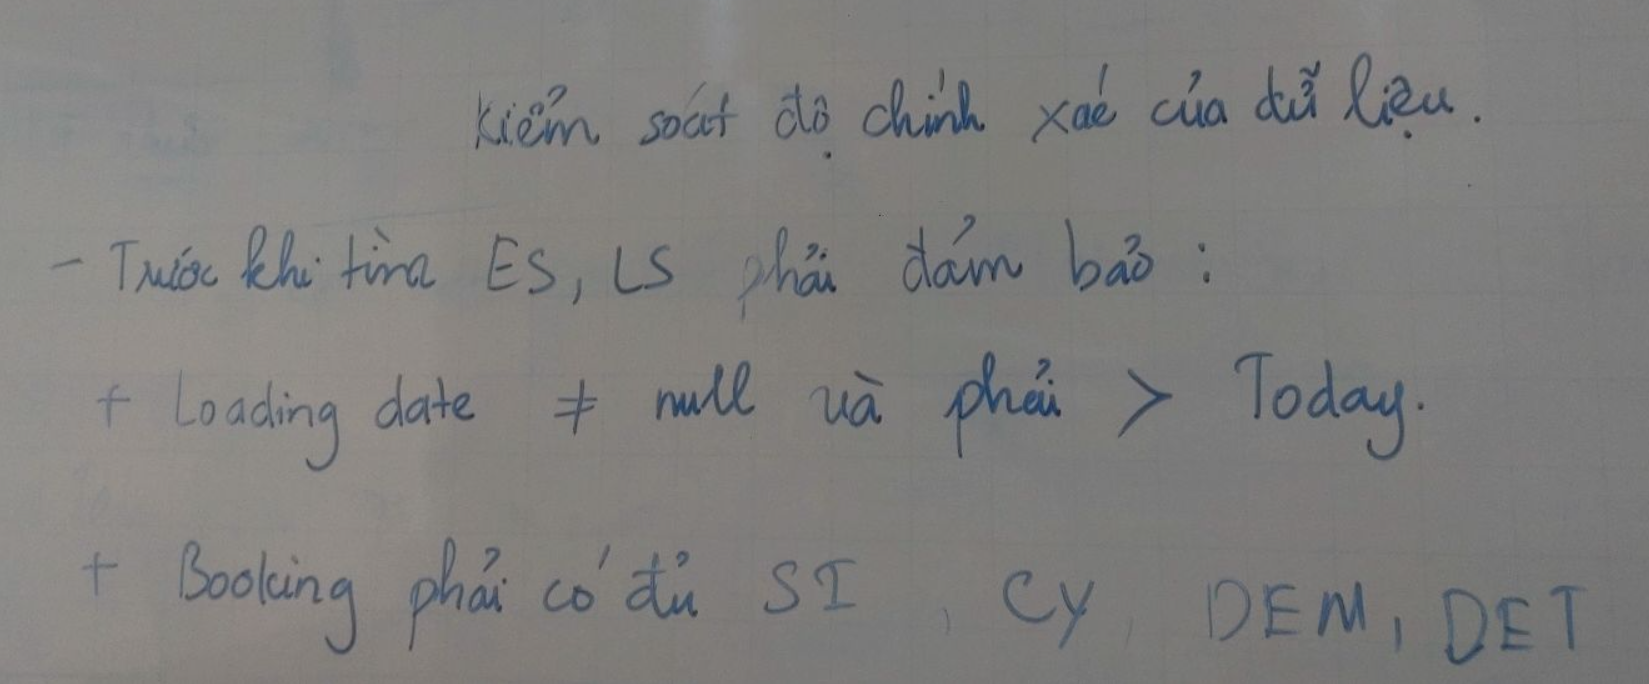

## cài đặt

In [ ]:
pip install pulp

In [ ]:
import pandas as pd
import numpy as np
import pulp
import datetime

import gspread
import gspread_dataframe as gd

from google.colab import data_table, auth
data_table.enable_dataframe_formatter()
auth.authenticate_user()

from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2 ĐỌC VÀ LÀM SẠCH DATA

In [ ]:
df_loading = pd.DataFrame.from_records(gc.open_by_url(loading_link).worksheet(loading_sheet).get(loading_range))
df_loading.columns = df_loading.iloc[0,:]
df_loading = df_loading.iloc[1:,:]
df_loading.columns = [col.strip() for col in df_loading.columns]
df_loading = df_loading.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df_loading.head()

,DS Week,Loading week (Actual),Lioness,Inco Term,FWD,Destination Port,DIV,SHIP-TO-CODE,LOADING METHOD,SUB SKU,...,Note S,ADDON SURCHARGE,PRODUCT SHORT DESCRIPTION,UNIT,PALLET MP,M3/PALLET,NET WEIGHT,GROSS WEIGHT(KG),COUNT PALLET,Total PCS
1,"WK07,2022",WK09,CX2,FOB,DHL,Buenaventura,Latam,11100037,Slip sheet,VN00025A,...,,,CTBM PREMIER_CLEAN FH M HGER12 LATAMX144,144.0,56.0,0.0,0.0,0.0,0.000,0.0
2,Wk13,WK13,CX2,FOB,DHL,Rotterdam Port,W.Europe,18010100,Slip sheet,61038992,...,,,CTBM SUPER SHINE FH M CEUR,48.0,168.0,29.4,2546.7,4046.62,31.000,249984.0
3,Wk13,WK13,CX2,FOB,DHL,Rotterdam Port,W.Europe,18010100,Slip sheet,61041843,...,,,CTBM TWISTER COLORS 3PK_EU,36.0,168.0,16.1,1362.3,2264.81,17.000,102816.0
4,Wk13,WK13,CX2,FOB,DHL,Rotterdam Port,W.Europe,18010100,Slip sheet,61040874,...,,,CTBM TWISTER FH M 1PK+CAP_EU*12,12.0,288.0,1.0,62.8,113.76,1.000,3456.0
5,Wk13,WK13,CX2,FOB,DHL,Rotterdam Port,W.Europe,18010100,Slip sheet,61030080,...,,,CTBM TRIPLE_ACTION FH M 4PK GBX24,24.0,288.0,11.2,988.4,1495.30,11.000,76032.0


In [ ]:
df_loading.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2163 entries, 1 to 2163
Data columns (total 78 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   DS Week                             2163 non-null   object
 1   Loading week (Actual)               2163 non-null   object
 2   Lioness                             2163 non-null   object
 3   Inco Term                           2163 non-null   object
 4   FWD                                 2163 non-null   object
 5   Destination Port                    2163 non-null   object
 6   DIV                                 2163 non-null   object
 7   SHIP-TO-CODE                        2163 non-null   object
 8   LOADING METHOD                      2163 non-null   object
 9   SUB SKU                             2163 non-null   object
 10  SUB                                 2163 non-null   object
 11  SKU                                 2163 non-null   obje

## giữ lại cột cần thiết

In [ ]:
# List of columns you want to keep
columns_to_keep = [
    'LOADING METHOD',
    'SUB',
    'STO 2/SO',
    'DELEVERY',
    'Container_Combine',
    'SIZE CONTAINER',
    'BOOKING NUMBER',
    'FINAL LOADING DATE',
    'ETD on Booking',
    'CUT OFF SI + VGM',
    'CLOSING TIME ON BOOKING',
    'DET',
    'DEM',
    'COUNT PALLET'
]
# Keep only the specified columns
df_loading = df_loading[columns_to_keep]
df_loading.head()

,LOADING METHOD,SUB,STO 2/SO,DELEVERY,Container_Combine,SIZE CONTAINER,BOOKING NUMBER,FINAL LOADING DATE,ETD on Booking,CUT OFF SI + VGM,CLOSING TIME ON BOOKING,DET,DEM,COUNT PALLET
1,Slip sheet,COLOMBIA,112536488,214265986,,40HC,76778657,2022-03-02,2022-03-07,03/3 10:00,2022-03-06,2022-02-28,2022-03-03,0.000
2,Slip sheet,NETHERLANDS,114206488,215852485,,40HC,YMJAN490382400,2024-03-27,2024-04-01,03/28 10:00,2024-03-29,2024-03-27,2024-03-27,31.000
3,Slip sheet,NETHERLANDS,114206488,215852485,,40HC,YMJAN490382400,2024-03-27,2024-04-01,03/28 10:00,2024-03-29,2024-03-27,2024-03-27,17.000
4,Slip sheet,NETHERLANDS,114206488,215852485,,40HC,YMJAN490382400,2024-03-27,2024-04-01,03/28 10:00,2024-03-29,2024-03-27,2024-03-27,1.000
5,Slip sheet,NETHERLANDS,114206488,215852485,,40HC,YMJAN490382400,2024-03-27,2024-04-01,03/28 10:00,2024-03-29,2024-03-27,2024-03-27,11.000


In [ ]:
# Replace 'FALSE' and '' with NaN (null) for the whole DataFrame, case-insensitive
df_loading.replace(to_replace=[r'(?i)^false$', ''], value=np.nan, regex=True, inplace=True)
df_loading.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2163 entries, 1 to 2163
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   LOADING METHOD           2163 non-null   object
 1   SUB                      2163 non-null   object
 2   STO 2/SO                 2158 non-null   object
 3   DELEVERY                 1410 non-null   object
 4   Container_Combine        35 non-null     object
 5   SIZE CONTAINER           2163 non-null   object
 6   BOOKING NUMBER           1741 non-null   object
 7   FINAL LOADING DATE       2157 non-null   object
 8   ETD on Booking           1740 non-null   object
 9   CUT OFF SI + VGM         1579 non-null   object
 10  CLOSING TIME ON BOOKING  1631 non-null   object
 11  DET                      1740 non-null   object
 12  DEM                      1740 non-null   object
 13  COUNT PALLET             2163 non-null   object
dtypes: object(14)
memory usage: 236.7+ KB


## xử lý date time

In [ ]:
# Define a custom function for the transformation
def add_year_si(row):
    cut_off = row['CUT OFF SI + VGM']
    closing_time = row['CLOSING TIME ON BOOKING']
    if pd.notnull(cut_off) and pd.notnull(closing_time):
        # Extract the first four characters of 'CLOSING TIME ON BOOKING' (the year)
        year = closing_time[:4]
        # Insert the year and '/' at the start of 'CUT OFF SI + VGM'
        cut_off = year + '/' + cut_off
    return cut_off

# Apply the custom function to each row
df_loading['CUT OFF SI + VGM'] = df_loading.apply(add_year_si, axis=1)
# Replace multiple whitespaces with a single space
df_loading['CUT OFF SI + VGM'] = df_loading['CUT OFF SI + VGM'].str.replace(r'\s+', ' ', regex=True)
df_loading.head()

,LOADING METHOD,SUB,STO 2/SO,DELEVERY,Container_Combine,SIZE CONTAINER,BOOKING NUMBER,FINAL LOADING DATE,ETD on Booking,CUT OFF SI + VGM,CLOSING TIME ON BOOKING,DET,DEM,COUNT PALLET
1,Slip sheet,COLOMBIA,112536488,214265986,NaN,40HC,76778657,2022-03-02,2022-03-07,2022/03/3 10:00,2022-03-06,2022-02-28,2022-03-03,0.000
2,Slip sheet,NETHERLANDS,114206488,215852485,NaN,40HC,YMJAN490382400,2024-03-27,2024-04-01,2024/03/28 10:00,2024-03-29,2024-03-27,2024-03-27,31.000
3,Slip sheet,NETHERLANDS,114206488,215852485,NaN,40HC,YMJAN490382400,2024-03-27,2024-04-01,2024/03/28 10:00,2024-03-29,2024-03-27,2024-03-27,17.000
4,Slip sheet,NETHERLANDS,114206488,215852485,NaN,40HC,YMJAN490382400,2024-03-27,2024-04-01,2024/03/28 10:00,2024-03-29,2024-03-27,2024-03-27,1.000
5,Slip sheet,NETHERLANDS,114206488,215852485,NaN,40HC,YMJAN490382400,2024-03-27,2024-04-01,2024/03/28 10:00,2024-03-29,2024-03-27,2024-03-27,11.000


In [ ]:
# Deal with datetime columns
df_loading['FINAL LOADING DATE'] = pd.to_datetime(df_loading['FINAL LOADING DATE'], format='%Y-%m-%d', errors='coerce')
df_loading['ETD on Booking'] = pd.to_datetime(df_loading['ETD on Booking'], format='%Y-%m-%d', errors='coerce')
df_loading['CUT OFF SI + VGM'] = pd.to_datetime(df_loading['CUT OFF SI + VGM'], format='%Y/%m/%d %H:%M', errors='coerce')
df_loading['CLOSING TIME ON BOOKING'] = pd.to_datetime(df_loading['CLOSING TIME ON BOOKING'], format='%Y-%m-%d', errors='coerce')
df_loading['DET'] = pd.to_datetime(df_loading['DET'], format='%Y-%m-%d', errors='coerce')
df_loading['DEM'] = pd.to_datetime(df_loading['DEM'], format='%Y-%m-%d', errors='coerce')

df_loading['DEM'] = df_loading['DEM'].apply(lambda x: pd.NaT if x.year == 1899 else x)
df_loading['DET'] = df_loading['DET'].apply(lambda x: pd.NaT if x.year == 1899 else x)

df_loading['COUNT PALLET'] = df_loading['COUNT PALLET'].astype(float)
df_loading.head()

,LOADING METHOD,SUB,STO 2/SO,DELEVERY,Container_Combine,SIZE CONTAINER,BOOKING NUMBER,FINAL LOADING DATE,ETD on Booking,CUT OFF SI + VGM,CLOSING TIME ON BOOKING,DET,DEM,COUNT PALLET
1,Slip sheet,COLOMBIA,112536488,214265986,NaN,40HC,76778657,2022-03-02,2022-03-07,2022-03-03 10:00:00,2022-03-06,2022-02-28,2022-03-03,0.0
2,Slip sheet,NETHERLANDS,114206488,215852485,NaN,40HC,YMJAN490382400,2024-03-27,2024-04-01,2024-03-28 10:00:00,2024-03-29,2024-03-27,2024-03-27,31.0
3,Slip sheet,NETHERLANDS,114206488,215852485,NaN,40HC,YMJAN490382400,2024-03-27,2024-04-01,2024-03-28 10:00:00,2024-03-29,2024-03-27,2024-03-27,17.0
4,Slip sheet,NETHERLANDS,114206488,215852485,NaN,40HC,YMJAN490382400,2024-03-27,2024-04-01,2024-03-28 10:00:00,2024-03-29,2024-03-27,2024-03-27,1.0
5,Slip sheet,NETHERLANDS,114206488,215852485,NaN,40HC,YMJAN490382400,2024-03-27,2024-04-01,2024-03-28 10:00:00,2024-03-29,2024-03-27,2024-03-27,11.0


In [ ]:
# Date of SI must < date ETD, if not, correct by minus 1 year
df_loading['CUT OFF SI + VGM'] = df_loading.apply(
    lambda row: row['CUT OFF SI + VGM'] - pd.DateOffset(years=1)
    if pd.notnull(row['CUT OFF SI + VGM']) and pd.notnull(row['ETD on Booking']) and
       row['CUT OFF SI + VGM'].date() > row['ETD on Booking'].date() else row['CUT OFF SI + VGM'],
    axis=1
)

## dữ liệu thô chưa filter

In [ ]:
# df_loading raw chưa filter gì cả, hoàn toàn giống với tất cả data trên google sheets
df_loading

In [ ]:
# Lưu lại df_loading ở hiện trạng lúc này
df_writeback = df_loading.copy()

## dữ liệu loading đã filter

In [ ]:
print("PHẢI CHẮC CHẮN RẰNG CÁC TẤT CẢ CỘT ĐƯỢC SỬ DỤNG ĐÃ CHÍNH XÁC, CỘT 'FINAL LOADING DATE' SẼ KHÔNG LẤY NGÀY QUÁ KHỨ")

In [ ]:
# Find the Saturday of next week
today = datetime.datetime.combine(datetime.date.today(), datetime.time.min)
days_until_this_saturday = (5 - today.weekday() + 7) % 7  # 5 is the weekday number for Saturday
saturday_of_this_week = today + datetime.timedelta(days=days_until_this_saturday)
saturday_of_next_week = saturday_of_this_week + datetime.timedelta(days=7)
saturday_of_next_week

In [ ]:
# df_loading đã filter ra những dòng cần để xếp plan cho tuần này
df_loading = df_loading[
    # 'DELEVERY' is null
    (df_loading['DELEVERY'].isnull()) &

    # 'SIZE CONTAINER' is not 'cancel'
    (df_loading['SIZE CONTAINER'].str.lower() != 'cancel') &

    # 'FINAL LOADING DATE' is not null and from today+1 to next Saturday
    (df_loading['FINAL LOADING DATE'].notnull()) &
    ((df_loading['FINAL LOADING DATE'] > today) & (df_loading['FINAL LOADING DATE'] <= saturday_of_next_week)) &

    # The following columns are not null
    (df_loading['STO 2/SO'].notnull() & df_loading['SUB'].notnull() & df_loading['LOADING METHOD'].notnull())
]
df_loading

In [ ]:
df_loading.info()

# 3 BOOKING ĐẶC BIỆT

In [ ]:
df_booking_special = df_loading[
    df_loading['SUB'].str.lower().apply(lambda x: any(x.startswith(sub) for sub in list_special_sub)) |
    df_loading['SIZE CONTAINER'].str.lower().apply(lambda x: any(x.startswith(sub) for sub in list_special_sub))
]
df_booking_special.head()

In [ ]:
df_booking_special.info()

## tách booking đặc biệt ra

In [ ]:
# Update df_loading to exclude rows that are in df_booking_special
df_loading = df_loading.drop(df_booking_special.index)

## sum pallet theo từng so

In [ ]:
# Tính tổng các pallet của từng SO duy nhất
aggregations_special = {
    'LOADING METHOD': 'first',
    'SUB': 'first',
    'DELEVERY': 'first',
    'Container_Combine': 'first',
    'SIZE CONTAINER': 'first',
    'BOOKING NUMBER': 'first',
    'FINAL LOADING DATE': 'first',
    'ETD on Booking': 'first',
    'CUT OFF SI + VGM': 'first',
    'CLOSING TIME ON BOOKING': 'first',
    'DET': 'first',
    'DEM': 'first',
    'COUNT PALLET': 'sum'
}
# Group by 'STO 2/SO' and apply the aggregation functions
df_booking_special = df_booking_special.groupby('STO 2/SO').agg(aggregations_special)
df_booking_special = df_booking_special.sort_values(by=['FINAL LOADING DATE', 'SUB', 'LOADING METHOD', 'Container_Combine', 'STO 2/SO']).reset_index()
df_booking_special.head()

In [ ]:
# Lưu lại mỗi SO tốn bao nhiêu pallet để ghi vào result
num_pallet_special = df_booking_special[['STO 2/SO', 'COUNT PALLET', 'LOADING METHOD']]

## tìm khoảng ngày khả thi

In [ ]:
df_booking_special['Earliest Start'] = df_booking_special['FINAL LOADING DATE']
df_booking_special['Latest Start'] = df_booking_special['FINAL LOADING DATE']

In [ ]:
# Đổi tên column 'STO 2/SO' thành 'STO 2/SO COMBINE' cho giống df_booking1 và df_booking0 bên dưới
df_booking_special.rename(columns={'STO 2/SO': 'STO 2/SO COMBINE'}, inplace=True)
df_booking_special

# 3 BOOKING ĐÃ CÓ

## kiểm tra cột SI, CY

In [ ]:
df_error1 = df_loading[
    (df_loading['CUT OFF SI + VGM'].isnull() & ~(df_loading['CLOSING TIME ON BOOKING'].isnull()) | df_loading['CLOSING TIME ON BOOKING'].isnull() & ~(df_loading['CUT OFF SI + VGM'].isnull())) &
    (~(df_loading['BOOKING NUMBER'].isnull()))
]
df_error1

In [ ]:
# Tạo lỗi ngưng chạy để cảnh báo khi thiếu thông tin CUT OFF, CLOSING
if len(df_error1)>0:
    raise ValueError("Kiểm tra lại cột CUT OFF SI/CLOSING")

## kiểm tra cột DEM, DET

In [ ]:
df_error2 = df_loading[
    (df_loading['DEM'].isnull() & ~(df_loading['DET'].isnull()) | df_loading['DET'].isnull() & ~(df_loading['DEM'].isnull())) &
    (~(df_loading['BOOKING NUMBER'].isnull()))
]
df_error2

In [ ]:
# Tạo lỗi ngưng chạy để cảnh báo khi thiếu thông tin DEM DET
if len(df_error2)>0:
    raise ValueError("Kiểm tra lại cột DEM/DET")

In [ ]:
df_booking1 = df_loading[
    # 'BOOKING NUMBER is not null
    (df_loading['BOOKING NUMBER'].notnull() &
    # The following datetime information columns are not null
    df_loading['CUT OFF SI + VGM'].notnull() & df_loading['CLOSING TIME ON BOOKING'].notnull() & df_loading['DET'].notnull() & df_loading['DEM'].notnull())
]
df_booking1.head()

In [ ]:
df_booking1.info()

## sum pallet theo từng so

In [ ]:
# Tính tổng các pallet của từng SO duy nhất
aggregations1_first = {
    'LOADING METHOD': 'first',
    'SUB': 'first',
    'DELEVERY': 'first',
    'Container_Combine': 'first',
    'SIZE CONTAINER': 'first',
    'BOOKING NUMBER': 'first',
    'FINAL LOADING DATE': 'first',
    'ETD on Booking': 'first',
    'CUT OFF SI + VGM': 'first',
    'CLOSING TIME ON BOOKING': 'first',
    'DET': 'first',
    'DEM': 'first',
    'COUNT PALLET': 'sum'
}
# Group by 'STO 2/SO' and apply the aggregation functions
df_booking1 = df_booking1.groupby('STO 2/SO').agg(aggregations1_first)
df_booking1 = df_booking1.sort_values(by=['FINAL LOADING DATE', 'BOOKING NUMBER', 'LOADING METHOD', 'Container_Combine', 'STO 2/SO']).reset_index()
df_booking1.head()

In [ ]:
# Lưu lại mỗi SO tốn bao nhiêu pallet để ghi vào result
num_pallet1 = df_booking1[['STO 2/SO', 'COUNT PALLET', 'LOADING METHOD']]

## cột phụ count

In [ ]:
# Tạo cột count theo rule nhóm các SO lại với nhau, mỗi nhóm bắt đầu từ số 1

In [ ]:
# Initialize the "Count" column with zeros
df_booking1['Count'] = 0

# Loop through the DataFrame rows using iterrows()
for index, row in df_booking1.iterrows():
    if index == 0:
        df_booking1.at[index, 'Count'] = 1
    else:
        prev_row = df_booking1.iloc[index - 1]
        if row['BOOKING NUMBER'] != prev_row['BOOKING NUMBER']:
            df_booking1.at[index, 'Count'] = 1
        else:
            if row['LOADING METHOD'] != prev_row['LOADING METHOD']:
                df_booking1.at[index, 'Count'] = 1
            else:
                if (row['Container_Combine'] == prev_row['Container_Combine']) & (row['Container_Combine'] is not None):
                    df_booking1.at[index, 'Count'] = prev_row['Count'] + 1
                else:
                    if prev_row['Count'] >= 3:
                        df_booking1.at[index, 'Count'] = 1
                    else:
                        df_booking1.at[index, 'Count'] = prev_row['Count'] + 1
df_booking1.head()

## nhóm so lại

In [ ]:
# Nhóm các nhóm lại dựa trên cột phụ Count

In [ ]:
df_booking1['Group'] = df_booking1['Count'].expanding().apply(lambda x: (x == 1).sum(), raw=True)
df_booking1.head()

In [ ]:
# Group by 'Group' and concatenate 'STO 2/SO' strings separated by ', '
df_booking1['STO 2/SO COMBINE'] = df_booking1.groupby('Group')['STO 2/SO'].transform(lambda x: ', '.join(x.astype(str)))
df_booking1.head()

## sum pallet theo nhóm so

In [ ]:
# Tính tổng các pallet của từng nhóm SO
aggregations1_second = {
    'LOADING METHOD': 'first',
    'SUB': 'first',
    'DELEVERY': 'first',
    'Container_Combine': 'first',
    'SIZE CONTAINER': 'first',
    'BOOKING NUMBER': 'first',
    'FINAL LOADING DATE': 'first',
    'ETD on Booking': 'first',
    'CUT OFF SI + VGM': 'first',
    'CLOSING TIME ON BOOKING': 'first',
    'DET': 'first',
    'DEM': 'first',
    'COUNT PALLET': 'sum'
}
# Group by 'STO 2/SO' and apply the aggregation functions
df_booking1 = df_booking1.groupby('STO 2/SO COMBINE').agg(aggregations1_second)
df_booking1 = df_booking1.sort_values(by=['FINAL LOADING DATE', 'BOOKING NUMBER', 'LOADING METHOD', 'Container_Combine']).reset_index()
df_booking1.head()

## tìm khoảng ngày khả thi

In [ ]:
# Get tomorrow's date as a Pandas Timestamp
tomorrow = pd.Timestamp(datetime.date.today()) + pd.Timedelta(days=1)
tomorrow

In [ ]:
# Define a custom function to calculate the 'Earliest Start' and 'Latest Start'
def calculate_start_dates_booking1(row):
    # Calculate 'Earliest Start'
    earliest_start = row['DEM'] if row['DET'] == row['DEM'] else row['DEM'] - pd.Timedelta(days=1)

    # Ensure 'Earliest Start' is not before tomorrow
    if earliest_start < tomorrow:
        earliest_start = tomorrow

    # If updated 'Earliest Start' is Sunday, set it to the following day (Monday)
    if earliest_start.weekday() == 6:  # 6 represents Sunday
        earliest_start += pd.Timedelta(days=1)

    # Calculate 'Latest Start'
    closing_time_minus_one_day = row['CLOSING TIME ON BOOKING'] - pd.Timedelta(days=1)
    if row['CUT OFF SI + VGM'].time() <= pd.Timestamp('09:00:00').time():
        cutoff_time = row['CUT OFF SI + VGM'] - pd.Timedelta(days=1)
    else:
        cutoff_time = row['CUT OFF SI + VGM']
    latest_start = min(closing_time_minus_one_day, cutoff_time)

    # If updated 'Latest Start' is Sunday, set it to the previous day (Satuday)
    if latest_start.weekday() == 6:  # 6 represents Sunday
        latest_start -= pd.Timedelta(days=1)

    return pd.Series([earliest_start, latest_start])

# Apply the custom function to each row to compute 'Earliest Start' and 'Latest Start'
df_booking1[['Earliest Start', 'Latest Start']] = df_booking1.apply(calculate_start_dates_booking1, axis=1)
df_booking1.head()

In [ ]:
# Change the time component to 00:00:00
df_booking1['Latest Start'] = df_booking1['Latest Start'].dt.normalize()
df_booking1

# 4 BOOKING CHƯA CÓ

In [ ]:
df_booking0 = df_loading[
    # 'BOOKING NUMBER' is null
    (df_loading['BOOKING NUMBER'].isnull())
]
df_booking0.head()

In [ ]:
df_booking0.info()

## sum pallet theo từng so

In [ ]:
# Tính tổng các pallet của từng SO duy nhất
aggregations0_first = {
    'LOADING METHOD': 'first',
    'SUB': 'first',
    'DELEVERY': 'first',
    'Container_Combine': 'first',
    'SIZE CONTAINER': 'first',
    'BOOKING NUMBER': 'first',
    'FINAL LOADING DATE': 'first',
    'ETD on Booking': 'first',
    'CUT OFF SI + VGM': 'first',
    'CLOSING TIME ON BOOKING': 'first',
    'DET': 'first',
    'DEM': 'first',
    'COUNT PALLET': 'sum'
}
# Group by 'STO 2/SO' and apply the aggregation functions
df_booking0 = df_booking0.groupby('STO 2/SO').agg(aggregations0_first)
df_booking0 = df_booking0.sort_values(by=['FINAL LOADING DATE', 'SUB', 'LOADING METHOD', 'Container_Combine', 'STO 2/SO']).reset_index()
df_booking0.head()

In [ ]:
# Lưu lại mỗi SO tốn bao nhiêu pallet để ghi vào result
num_pallet0 = df_booking0[['STO 2/SO', 'COUNT PALLET', 'LOADING METHOD']]

## cột phụ count

In [ ]:
# Tạo cột count theo rule nhóm các SO lại với nhau, mỗi nhóm bắt đầu từ số 1

In [ ]:
# Initialize the "Count" column with zeros
df_booking0['Count'] = 0

# Loop through the DataFrame rows using iterrows()
for index, row in df_booking0.iterrows():
    if index == 0:
        df_booking0.at[index, 'Count'] = 1
    else:
        prev_row = df_booking0.iloc[index - 1]
        if row['FINAL LOADING DATE'] != prev_row['FINAL LOADING DATE']:
            df_booking0.at[index, 'Count'] = 1
        else:
            if row['SUB'] != prev_row['SUB']:
                df_booking0.at[index, 'Count'] = 1
            else:
                if row['LOADING METHOD'] != prev_row['LOADING METHOD']:
                    df_booking0.at[index, 'Count'] = 1
                else:
                    if (row['Container_Combine'] == prev_row['Container_Combine']) & (row['Container_Combine'] is not None):
                        df_booking0.at[index, 'Count'] = prev_row['Count'] + 1
                    else:
                        if prev_row['Count'] >= 3:
                            df_booking0.at[index, 'Count'] = 1
                        else:
                            df_booking0.at[index, 'Count'] = prev_row['Count'] + 1
df_booking0.head()

## nhóm so lại

In [ ]:
# Nhóm các nhóm lại dựa trên cột phụ Count

In [ ]:
df_booking0['Group'] = df_booking0['Count'].expanding().apply(lambda x: (x == 1).sum(), raw=True)
df_booking0.head()

In [ ]:
# Group by 'Group' and concatenate 'STO 2/SO' strings separated by ', '
df_booking0['STO 2/SO COMBINE'] = df_booking0.groupby('Group')['STO 2/SO'].transform(lambda x: ', '.join(x.astype(str)))
df_booking0.head()

## sum pallet theo nhóm so

In [ ]:
# Tính tổng các pallet của từng nhóm SO
aggregations0_second = {
    'LOADING METHOD': 'first',
    'SUB': 'first',
    'DELEVERY': 'first',
    'Container_Combine': 'first',
    'SIZE CONTAINER': 'first',
    'BOOKING NUMBER': 'first',
    'FINAL LOADING DATE': 'first',
    'ETD on Booking': 'first',
    'CUT OFF SI + VGM': 'first',
    'CLOSING TIME ON BOOKING': 'first',
    'DET': 'first',
    'DEM': 'first',
    'COUNT PALLET': 'sum'
}
# Group by 'STO 2/SO' and apply the aggregation functions
df_booking0 = df_booking0.groupby('STO 2/SO COMBINE').agg(aggregations0_second)
df_booking0 = df_booking0.sort_values(by=['FINAL LOADING DATE', 'BOOKING NUMBER', 'LOADING METHOD', 'Container_Combine']).reset_index()
df_booking0.head()

## tìm khoảng ngày khả thi

In [ ]:
# Get today's date as a Pandas Timestamp
today = pd.Timestamp(datetime.date.today())
today

In [ ]:
# Define a function to calculate 'Earliest Start' and 'Latest Start' based on the day of the week
def calculate_start_dates_booking0(row):
    final_loading_date = pd.Timestamp(row['FINAL LOADING DATE'])

    if today.weekday() in [6, 0, 1, 2]:  # Sunday, Monday, Tuesday, Wednesday
        if today <= final_loading_date <= today + pd.Timedelta(days=2):
            earliest_start = today + pd.Timedelta(days=3)
        else:
            earliest_start = final_loading_date
    elif today.weekday() in [3, 4, 5]:  # Thursday, Friday, Saturday
        if today <= final_loading_date <= today + pd.Timedelta(days=4):
            earliest_start = today + pd.Timedelta(days=5)
        else:
            earliest_start = final_loading_date

    # Calculate the Saturday of the week for the 'earliest_start'
    saturday_of_earliest_start = earliest_start + pd.Timedelta(days=(5 - earliest_start.weekday()) % 7)

    # If 'earliest_start' is already a Saturday, use it as 'latest_start'
    if earliest_start.weekday() == 5:
        latest_start = earliest_start
    else:
        # Otherwise, 'latest_start' is the next Saturday after 'earliest_start'
        latest_start = saturday_of_earliest_start

    return pd.Series([earliest_start, latest_start])

# Apply the function to each row of df_booking0
df_booking0[['Earliest Start', 'Latest Start']] = df_booking0.apply(calculate_start_dates_booking0, axis=1)
df_booking0

# 5 GỘP BA LOẠI BOOKING LẠI

In [ ]:
# Append df_booking_special and df_booking1 and df_booking0 vertically
df_booking = pd.concat([df_booking_special, df_booking1, df_booking0], ignore_index=True)
df_booking

In [ ]:
df_booking.info()

### sửa lại nếu ES > LS

In [ ]:
df_booking[df_booking['Earliest Start'] > df_booking['Latest Start']]

In [ ]:
# Update 'Earliest Start' and 'Latest Start' = Loading Date where 'Earliest Start' is greater than 'Latest Start'
df_booking.loc[df_booking['Earliest Start'] > df_booking['Latest Start'], ['Earliest Start', 'Latest Start']] = df_booking['FINAL LOADING DATE']

## sửa lại nếu tuần ES != tuần LS

In [ ]:
# khi w ES != w LS, nếu w Loading = w ES thì kéo LS lên thứ 7 w Loading, ngược lại nếu w Loading = w LS thì lùi ES xuống thứ 2 w Loading

In [ ]:
# Find rows where 'Earliest Start' and 'Latest Start' are not in the same week
df_booking[df_booking['Earliest Start'].dt.isocalendar().week != df_booking['Latest Start'].dt.isocalendar().week]

In [ ]:
# Define a custom function for the transformation
def update_start_dates_in_different_week(row):
    # Extract the week numbers
    week_of_earliest = row['Earliest Start'].isocalendar()[1]
    week_of_latest = row['Latest Start'].isocalendar()[1]
    week_of_final_loading = row['FINAL LOADING DATE'].isocalendar()[1]

    # Check if the week numbers of 'Earliest Start' and 'Latest Start' are different
    if week_of_earliest != week_of_latest:
        # If week of 'Earliest Start' equals week number of 'FINAL LOADING DATE'
        if week_of_earliest == week_of_final_loading:
            # Update 'Latest Start' to the Saturday of the week of 'FINAL LOADING DATE'
            row['Latest Start'] = row['FINAL LOADING DATE'] + pd.DateOffset(days=(5 - row['FINAL LOADING DATE'].weekday()))
        # If week of 'Latest Start' equals week number of 'FINAL LOADING DATE'
        elif week_of_latest == week_of_final_loading:
            # Update 'Earliest Start' to the Monday of the week of 'FINAL LOADING DATE'
            row['Earliest Start'] = row['FINAL LOADING DATE'] - pd.DateOffset(days=row['FINAL LOADING DATE'].weekday())
    return row

# Apply the custom function to each row
df_booking = df_booking.apply(update_start_dates_in_different_week, axis=1)
df_booking.head()

## kiểm tra cột ES, LS

In [ ]:
# kiểm tra có ES là chủ nhật
df_booking[df_booking['Earliest Start'].dt.weekday == 6]

In [ ]:
# kiểm tra có LS là chủ nhật
df_booking[df_booking['Latest Start'].dt.weekday == 6]

In [ ]:
# kiểm tra có ES là quá khứ
df_booking[df_booking['Earliest Start'] < tomorrow]

In [ ]:
# kiểm tra có thiếu ES hoặc LS
df_booking[df_booking['Earliest Start'].isnull() | df_booking['Latest Start'].isnull()]

In [ ]:
df_error3 = df_booking[
    (df_booking['Earliest Start'].dt.weekday == 6) |
    (df_booking['Latest Start'].dt.weekday == 6) |
    (df_booking['Earliest Start'] < tomorrow) |
    (df_booking['Earliest Start'].isnull() | df_booking['Latest Start'].isnull())
]
df_error3

In [ ]:
# Tạo lỗi ngưng chạy để cảnh báo khi thiếu thông tin ES LS
if len(df_error3)>0:
    raise ValueError("Kiểm tra lại cột ES LS")

## tất cả booking cần xếp

In [ ]:
# Filter df_booking trong vòng tuần này và tuần sau

In [ ]:
# Get the current date
current_date = datetime.datetime.now()
# Get the current week number and the next week number
current_week_number = current_date.isocalendar()[1]
next_week_number = (current_date + datetime.timedelta(weeks=1)).isocalendar()[1]

# Filter df_booking for rows where 'Week' is the current week number or the next week number
df_booking = df_booking[
    (df_booking['Earliest Start'].dt.isocalendar().week == current_week_number) | (df_booking['Earliest Start'].dt.isocalendar().week == next_week_number)
]
df_booking

In [ ]:
df_booking.info()

# 6 CHỌN NGÀY TỐI ƯU

## hàm chọn ngày tối ưu

In [ ]:
# def optimize_pallet_assignment(df):
#     # Create a list of all possible dates within the earliest and latest start dates
#     all_dates = pd.date_range(start=df['Earliest Start'].min(), end=df['Latest Start'].max())

#     # Initialize the linear programming problem
#     prob = pulp.LpProblem("PalletLoadingProblem", pulp.LpMinimize)

#     # Create a dictionary to hold the decision variables
#     # Each variable represents whether a row (pallet set) is assigned to a date
#     x = {(index, date): pulp.LpVariable(f"x_{index}_{date.date()}", cat='Binary')
#          for date in all_dates for index in df.index}

#     # Create an auxiliary variable to represent the maximum total COUNT PALLET in each date
#     max_pallets = pulp.LpVariable("max_pallets", lowBound=0, cat='Continuous')

#     # Objective function: Minimize the auxiliary variable
#     prob += max_pallets

#     # Constraint to ensure each row (pallet set) must be assigned to exactly one date within its range
#     for index, row in df.iterrows():
#         prob += pulp.lpSum(x[(index, date)] for date in all_dates if row['Earliest Start'] <= date <= row['Latest Start']) == 1

#     # Constraint to ensure max_pallets is greater than or equal to the total pallets for each date
#     for date in all_dates:
#         prob += max_pallets >= pulp.lpSum(row['COUNT PALLET'] * x[(index, date)] for index, row in df.iterrows())

#     # Solve the problem
#     prob.solve()

#     # Assign the solution date to each row in the DataFrame
#     for index, row in df.iterrows():
#         for date in all_dates:
#             if pulp.value(x[(index, date)]) == 1:
#                 df.at[index, 'Solution Date'] = date
#                 break

#     return df

In [ ]:
unavailable_dates = [pd.Timestamp(date_str) for date_str in unavailable_dates]

In [ ]:
def optimize_pallet_assignment(df, unavailable_dates):
    # Create a list of all possible dates within the earliest and latest start dates
    all_dates = pd.date_range(start=df['Earliest Start'].min(), end=df['Latest Start'].max())

    # Remove unavailable dates from consideration
    all_dates = [date for date in all_dates if date not in unavailable_dates]

    # Initialize the linear programming problem
    prob = pulp.LpProblem("PalletLoadingProblem", pulp.LpMinimize)

    # Create a dictionary to hold the decision variables
    # Each variable represents whether a row (pallet set) is assigned to a date
    x = {(index, date): pulp.LpVariable(f"x_{index}_{date.date()}", cat='Binary')
         for date in all_dates for index in df.index}

    # Create an auxiliary variable to represent the maximum total COUNT PALLET in each date
    max_pallets = pulp.LpVariable("max_pallets", lowBound=0, cat='Continuous')

    # Objective function: Minimize the auxiliary variable
    prob += max_pallets

    # Constraint to ensure each row (pallet set) must be assigned to exactly one date within its range
    for index, row in df.iterrows():
        prob += pulp.lpSum(x[(index, date)] for date in all_dates if row['Earliest Start'] <= date <= row['Latest Start']) == 1

    # Constraint to ensure max_pallets is greater than or equal to the total pallets for each date
    for date in all_dates:
        prob += max_pallets >= pulp.lpSum(row['COUNT PALLET'] * x[(index, date)] for index, row in df.iterrows())

    # Solve the problem
    prob.solve()

    # Assign the solution date to each row in the DataFrame
    for index, row in df.iterrows():
        for date in all_dates:
            if pulp.value(x[(index, date)]) == 1:
                df.at[index, 'Solution Date'] = date
                break

    return df

## booking floor floading tuần này

In [ ]:
# Filter for Floor Loading and current week number
df_booking_week_n_fl = df_booking[
    (df_booking['LOADING METHOD'] == "Floor Loading") &
    (df_booking['Earliest Start'].dt.isocalendar().week == current_week_number)
]
df_booking_week_n_fl = df_booking_week_n_fl[['STO 2/SO COMBINE','COUNT PALLET','Earliest Start','Latest Start']]

In [ ]:
if len(df_booking_week_n_fl)>0:
    optimize_pallet_assignment(df_booking_week_n_fl, unavailable_dates)
df_booking_week_n_fl

## booking slip sheet tuần này

In [ ]:
# Filter for Slip Sheet and current week number
df_booking_week_n_sl = df_booking[
    (df_booking['LOADING METHOD'] == "Slip sheet") &
    (df_booking['Earliest Start'].dt.isocalendar().week == current_week_number)
]
df_booking_week_n_sl = df_booking_week_n_sl[['STO 2/SO COMBINE','COUNT PALLET','Earliest Start','Latest Start']]

In [ ]:
if len(df_booking_week_n_sl)>0:
    optimize_pallet_assignment(df_booking_week_n_sl, unavailable_dates)
df_booking_week_n_sl

## booking floor floading tuần sau

In [ ]:
# Filter for Floor Loading and next week number
df_booking_week_n1_fl = df_booking[
    (df_booking['LOADING METHOD'] == "Floor Loading") &
    (df_booking['Earliest Start'].dt.isocalendar().week == next_week_number)
]
df_booking_week_n1_fl = df_booking_week_n1_fl[['STO 2/SO COMBINE','COUNT PALLET','Earliest Start','Latest Start']]

In [ ]:
if len(df_booking_week_n1_fl)>0:
    optimize_pallet_assignment(df_booking_week_n1_fl, unavailable_dates)
df_booking_week_n1_fl

## booking slip sheet tuần sau

In [ ]:
# Filter for Slip Sheet and next week number
df_booking_week_n1_sl = df_booking[
    (df_booking['LOADING METHOD'] == "Slip sheet") &
    (df_booking['Earliest Start'].dt.isocalendar().week == next_week_number)
]
df_booking_week_n1_sl = df_booking_week_n1_sl[['STO 2/SO COMBINE','COUNT PALLET','Earliest Start','Latest Start']]

In [ ]:
if len(df_booking_week_n1_sl)>0:
    optimize_pallet_assignment(df_booking_week_n1_sl, unavailable_dates)
df_booking_week_n1_sl

## kết quả cuối cùng

In [ ]:
# Create df_result as an empty DataFrame
df_result = pd.DataFrame()

# Concatenate df_booking_week_n_fl if it has rows
if len(df_booking_week_n_fl) > 0:
    df_result = pd.concat([df_result, df_booking_week_n_fl])

# Concatenate df_booking_week_n_sl if it has rows
if len(df_booking_week_n_sl) > 0:
    df_result = pd.concat([df_result, df_booking_week_n_sl])

# Concatenate df_booking_week_n1_fl if it has rows
if len(df_booking_week_n1_fl) > 0:
    df_result = pd.concat([df_result, df_booking_week_n1_fl])

# Concatenate df_booking_week_n1_sl if it has rows
if len(df_booking_week_n1_sl) > 0:
    df_result = pd.concat([df_result, df_booking_week_n1_sl])

df_result = df_result[['STO 2/SO COMBINE','Earliest Start','Latest Start','Solution Date']]
df_result.rename(columns={'STO 2/SO COMBINE': 'STO 2/SO'}, inplace=True)
df_result.head()

In [ ]:
# Split values in 'STO 2/SO' column by comma and expand them into multiple columns
df_result = df_result.assign(**{'STO 2/SO': df_result['STO 2/SO'].str.split(', ')}) \
                     .explode('STO 2/SO') \
                     .reset_index(drop=True)
df_result.head()

In [ ]:
num_pallet = pd.concat([num_pallet_special, num_pallet1, num_pallet0], axis=0)

In [ ]:
df_result = df_result.merge(num_pallet, how='left', on='STO 2/SO')
df_result.head()

In [ ]:
# Sort df_result by 'Solution Date' and 'STO 2/SO'
df_result = df_result.sort_values(by=['Solution Date', 'LOADING METHOD', 'STO 2/SO'])
# Reset index of the DataFrame
df_result.reset_index(drop=True, inplace=True)
df_result

# 7 GHI KẾT QUẢ

## kết quả thuần

In [ ]:
# Clear the existing contents in the result sheet
result_wb = gc.open_by_url(loading_link)
result_wb_sheet = result_wb.worksheet(result_sheet)
# result_wb_sheet.clear() # xóa cả sheet
result_wb.values_clear(f"{result_sheet}!{result_range}") # xóa 1 vùng

# Write DataFrame to Google Sheets
gd.set_with_dataframe(result_wb_sheet, df_result)

In [ ]:
print('Done')

## cập nhật lại cột Final Loading Date

In [ ]:
# cập nhật lại cột final loading date luôn để đỡ chỉnh tay và lưu trữ lịch sử
# cập nhật lại loading date cho chưa có booking là ES
# cập nhật lại loading date cho đã có booking là Solution Date
# những trường hợp không nằm trong list balance thì giữ nguyên final loading date

In [ ]:
df_writeback = df_writeback[['STO 2/SO', 'DELEVERY', 'FINAL LOADING DATE', 'SIZE CONTAINER', 'BOOKING NUMBER']]
df_writeback.head()

In [ ]:
df_writeback = df_writeback.merge(df_result, how='left', on='STO 2/SO')
df_writeback

In [ ]:
# Define the custom function to update 'FINAL LOADING DATE'
def update_final_loading_date(row):
    if (pd.isnull(row['DELEVERY']) and
        pd.isnull(row['BOOKING NUMBER']) and
        pd.notnull(row['Earliest Start']) and
        row['SIZE CONTAINER'].lower() != 'cancel'):
        return row['Earliest Start']    # cập nhật lại loading date cho chưa có booking là ES
    elif (pd.isnull(row['DELEVERY']) and
          pd.notnull(row['BOOKING NUMBER']) and
          pd.notnull(row['Earliest Start']) and
          row['SIZE CONTAINER'].lower() != 'cancel'):
        return row['Solution Date']   # lưu lại kết quả tìm được cho đã có booking
    else:
        return row['FINAL LOADING DATE'] # những trường hợp không nằm trong df_result thì giữ nguyên

# Apply the custom function to each row
df_writeback['FINAL LOADING DATE'] = df_writeback.apply(update_final_loading_date, axis=1)
df_writeback

In [ ]:
# Open the Google Sheet by URL
spreadsheet = gc.open_by_url(loading_link)

# Select the worksheet
worksheet = spreadsheet.worksheet(writeback_sheet)

# Get the data from df_writeback['FINAL LOADING DATE']
final_loading_dates = df_writeback['FINAL LOADING DATE'].apply(lambda x: x.strftime('%Y-%m-%d') if pd.notnull(x) else '').tolist()

# Write the data to the specified range starting from X2
start_row = 2
cell_range = f'{writeback_column}{start_row}:{writeback_column}{start_row + len(final_loading_dates) - 1}'
cell_list = worksheet.range(cell_range)

for i, cell in enumerate(cell_list):
    cell.value = final_loading_dates[i]

worksheet.update_cells(cell_list)

print("Data written successfully.")

In [ ]:
print('Done')

+ đã có booking: null delivery, có booking, loading date from today + 1 to end of next week and not null, booking != vietnam, size cont != cancel, ko null ở bất kì cột date nào
+ chưa có booking:booking null, today+1 to end of next week

+ lấy cột Z để biết gom SO chung


In [ ]:
# df_loading[df_loading['Loading week (Actual)']=='9999']

In [ ]:
# pip install ortools

In [ ]:
# from ortools.sat.python import cp_model

# # Data
# bookings = [
#     {'name': 'A1', 'pallets': 3, 'available_days': [True, True, True, False, False, False]},
#     {'name': 'A2', 'pallets': 4, 'available_days': [True, True, False, False, False, False]},
#     {'name': 'A3', 'pallets': 5, 'available_days': [False, True, True, True, False, False]},
#     {'name': 'B1', 'pallets': 6, 'available_days': [False, False, False, True, True, True]},
#     {'name': 'B2', 'pallets': 4, 'available_days': [False, False, False, False, True, True]},
#     {'name': 'C1', 'pallets': 7, 'available_days': [False, False, True, True, True, False]},
#     {'name': 'D1', 'pallets': 10, 'available_days': [False, True, True, False, False, False]},
#     {'name': 'D2', 'pallets': 9, 'available_days': [True, True, True, True, False, False]},
#     {'name': 'E1', 'pallets': 8, 'available_days': [False, True, True, True, True, True]},
# ]

# # Number of days
# num_days = 6

# # Create the model
# model = cp_model.CpModel()

# # Variables
# x = {}  # x[(i, j)] is a boolean variable, true if booking i is assigned to day j.
# for i, booking in enumerate(bookings):
#     for j in range(num_days):
#         if booking['available_days'][j]:
#             x[(i, j)] = model.NewBoolVar(f'x[{i},{j}]')

# # Constraints
# # Each booking must be assigned to exactly one day.
# for i, booking in enumerate(bookings):
#     model.Add(sum(x[(i, j)] for j in range(num_days) if (i, j) in x) == 1)

# # Objective
# # Minimize the maximum number of pallets loaded on any day.
# total_pallets = [model.NewIntVar(0, sum(b['pallets'] for b in bookings), f'total_pallets[{j}]') for j in range(num_days)]
# for j in range(num_days):
#     model.Add(total_pallets[j] == sum(x[(i, j)] * bookings[i]['pallets'] for i in range(len(bookings)) if (i, j) in x))
# max_pallets = model.NewIntVar(0, sum(b['pallets'] for b in bookings), 'max_pallets')
# model.AddMaxEquality(max_pallets, total_pallets)
# model.Minimize(max_pallets)

# # Solve the model
# solver = cp_model.CpSolver()
# status = solver.Solve(model)

# # Print solution
# if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
#     print('Solution:')
#     print('B\tP\tT2\tT3\tT4\tT5\tT6\tT7')
#     for i, booking in enumerate(bookings):
#         print(f"{booking['name']}\t{booking['pallets']}\t", end='')
#         for j in range(num_days):
#             if (i, j) in x and solver.Value(x[(i, j)]) == 1:
#                 print('1\t', end='')
#             else:
#                 print('0\t', end='')
#         print()
# else:
#     print('No solution found.')

In [ ]:
# status